# Cheated library: can the plain `ProfileMLP` learn the TRUE top-500 variants once it sees them directly?

Follow-up to `MLP_bilinear_head_anticorrelated.ipynb` / `MLP_for_anticorrelated_weights.ipynb`. Those
notebooks found that a plain `ProfileMLP` (no bilinear head) badly under-predicts the TRUE top-K
global-optimum variants -- the ones dominated by `J` (pairwise/epistatic), not `F` (additive) -- when
those variants are never seen during training. That's consistent with two very different explanations:

1. **Out-of-distribution / generalization gap**: the model *could* represent these points fine, it just
   never saw anything resembling them in the random training pool (the TRUE top-500 are an astronomically
   rare corner of `20**7` possible sequences).
2. **Capacity / optimization limit**: a plain MLP genuinely struggles to fit exact bilinear (Potts-style)
   structure, even if given direct supervision on those exact points.

This notebook retrieves the TRUE top-500 variants by brute force against the ground-truth `F`/`J`
landscape (same `K_BEST = 500` convention as `MLP_bilinear_head_anticorrelated.ipynb` section 5) and
injects them into the training set of the plain `ProfileMLP` (NOT the bilinear-head variant), to check
whether merely including them in the library is enough to fix the prediction gap.

> **2026-08-13 revision.** The original version of this notebook (see section 5's docstring for the
> details) injected the top-500 with their exact **noiseless `compute_score`** as the training label --
> a pure "cheat control" that hands the model the literal right answer. That's been replaced with a more
> realistic design: the top-500 are injected into the **sequence pool** and run through the full
> simulated experiment (`ProtocolV3.N_loop_DE` -- dilution, PCR, NGS noise), so they get the same kind of
> noisy, NGS-measured log enrichment as every other sequence. This asks a practically useful question --
> "would spiking a real mutagenesis library with designed sequences actually help" -- rather than the
> more idealized "can the model memorize the exact right answer."

- If augmentation **collapses** the gap (predicted values for the top-500 cluster at the right edge,
  residual vs. `J_part` flattens toward 0) -> the earlier failure was mostly an OOD/generalization issue
  that a realistically-designed library could fix in practice.
- If augmentation does **not** fix it -> either a genuine capacity/optimization limit, or realistic NGS
  noise itself destroys too much of the signal a cleaner "cheat" would have provided.

Same ground truth (`F_viab`/`J_viab`, real AAV9 -- now the credible, naive-retrieval + L2-attenuated GT
at `REG_STRENGTH=5`, loaded automatically via `load_F_viab_aav9_mlp`/`load_J_viab_aav9_mlp`), same
anticorrelated `F_sel`/`J_sel` (`anticorrelation=0.2`, `key=10`), and the same cached datasets as the
sibling notebooks.

## 0. Setup

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as the sibling notebooks.

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import (
    load_F_viab_aav9_mlp, load_J_viab_aav9_mlp,
    initialize_anticorrelated_weights,
    NUM_AMINO_ACIDS, NUM_POSITIONS,
)

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Ground truth + cached datasets

Same `F_viab`/`J_viab` (real AAV9) and `F_sel_anti`/`J_sel_anti` (`anticorrelation=0.2`, `key=10`) as
`MLP_for_anticorrelated_weights.ipynb` and `MLP_bilinear_head_anticorrelated.ipynb`, and the same
`sequences`/`sequences2` (identical seeds), so `dataset_filename` resolves to the exact CSVs those
notebooks already cached on disk -- no new simulation needed here.

F_viab shape: (20, 7)   J_viab shape: (7, 7, 20, 20)


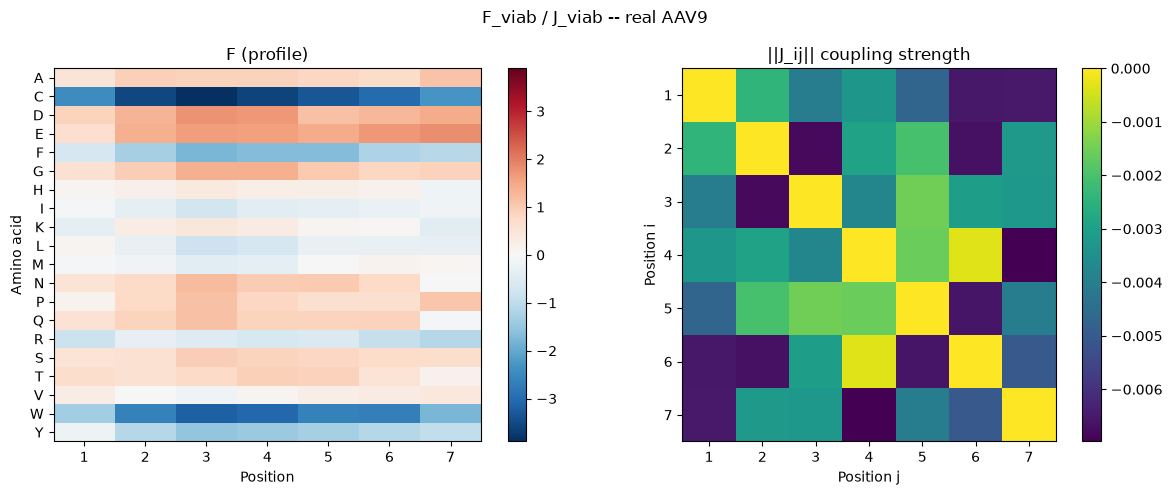

In [3]:
F_viab = load_F_viab_aav9_mlp()
J_viab = load_J_viab_aav9_mlp()

anticorrelation = 0.2
F_sel_anti, J_sel_anti = initialize_anticorrelated_weights(jax.random.key(10), F_viab, J_viab, anticorrelation)

print(f"F_viab shape: {F_viab.shape}   J_viab shape: {J_viab.shape}")
_ = plot_teacher_weights(F_viab, J_viab, title="F_viab / J_viab -- real AAV9")
plt.show()

In [4]:
def dataset_filename(protocol, label):
    def fmt(v):
        return f"{float(v):g}".replace(".", "")

    if protocol.noise_viab == protocol.noise_sel:
        noise_part = f"noise{fmt(protocol.noise_viab)}"
    else:
        noise_part = f"noiseviab{fmt(protocol.noise_viab)}_noisesel{fmt(protocol.noise_sel)}"

    return (f"diversity{protocol.d0}_Tsel{fmt(protocol._T_sel)}"
            f"_Tviab{fmt(protocol._T_viab)}_{noise_part}_{label}.csv")


def build_or_load_dataset(protocol, sequences, log_enr_viab, log_enr_sel, label):
    """(sequence, target1=viability log-enrichment, target2=selectivity log-enrichment)
    dataset for this protocol's parameters -- identical to the sibling notebooks' version. Loads
    the CSV from disk if it was already generated for this exact (diversity, T_sel, T_viab, noise,
    label) combination, else builds and saves it."""
    path = dataset_filename(protocol, label)
    if os.path.exists(path):
        print(f"{path} already exists -- loading from disk")
        return pd.read_csv(path)

    seq_strings = ["".join(AA_LABELS[a] for a in row) for row in np.asarray(sequences)]
    df = pd.DataFrame({"sequence": seq_strings, "target1": log_enr_viab, "target2": log_enr_sel})
    df.to_csv(path, index=False)
    print(f"saved {path} ({len(df)} rows)")
    return df

In [5]:
key = jax.random.key(0)
key, k_seq = jax.random.split(key)

N = 20_000
sequences = jax.random.randint(k_seq, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

protocol_anti = ProtocolV3(N0=1_000_000_000, N1=500_000_000,
        dilution_factor=10, sequences=sequences, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_anti, J_sel=J_sel_anti,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )

# NOTE (2026-08-13): the cached CSV this used to silently load was cleared along with every
# other stale cache built from the pre-REG=5 GT (see AAV9_profile_model.ipynb 3c) -- always
# compute log_enr_viab/log_enr_sel here directly (same recipe as
# MLP_for_anticorrelated_weights.ipynb section 1); build_or_load_dataset's own existence
# check handles the caching, no need to duplicate it here.
_bio_row, _ngs_row = protocol_anti.N_loop_DE(1)[0]
_lambda0p, _lambda2p, _lambda3p = (np.asarray(x) for x in _ngs_row)
_eps = 1.0
log_enr_viab = np.log((_lambda2p + _eps) / (_lambda0p + _eps))
log_enr_sel  = np.log((_lambda3p + _eps) / (_lambda2p + _eps))

dataset_anti = build_or_load_dataset(protocol_anti, sequences, log_enr_viab, log_enr_sel, label="ac")
print(f"dataset_anti: {len(dataset_anti):,} rows")
dataset_anti.head()

Directed evolution rounds: 100%|██████████| 1/1 [00:05<00:00,  5.09s/it]

diversity20000_Tsel1_Tviab1_noise05_ac.csv already exists -- loading from disk
dataset_anti: 20,000 rows


,sequence,target1,target2
0,DDTSNIP,1.672505,-9.522406
1,MSTDFNG,0.408340,-1.122382
2,CQNSWCF,-8.055339,-1.540445
3,CRCHSEA,-8.460856,3.234749
4,QAFNMTQ,-3.161586,1.031805


In [6]:
key = jax.random.key(42)
key, k_seq = jax.random.split(key)

N = 2_000_000
sequences2 = jax.random.randint(k_seq, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

protocol_anti2 = ProtocolV3(N0=1_000_000_000, N1=500_000_000,
        dilution_factor=10, sequences=sequences2, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_anti, J_sel=J_sel_anti,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )

# Same note as above -- always compute directly since the old cache was cleared.
_bio_row2, _ngs_row2 = protocol_anti2.N_loop_DE(1)[0]
_lambda0p2, _lambda2p2, _lambda3p2 = (np.asarray(x) for x in _ngs_row2)
_eps = 1.0
log_enr_viab2 = np.log((_lambda2p2 + _eps) / (_lambda0p2 + _eps))
log_enr_sel2  = np.log((_lambda3p2 + _eps) / (_lambda2p2 + _eps))

dataset_anti2 = build_or_load_dataset(protocol_anti2, sequences2, log_enr_viab2, log_enr_sel2, label="ac")
print(f"dataset_anti2: {len(dataset_anti2):,} rows")

Directed evolution rounds: 100%|██████████| 1/1 [00:06<00:00,  6.12s/it]


diversity2000000_Tsel1_Tviab1_noise05_ac.csv already exists -- loading from disk
dataset_anti2: 2,000,000 rows


## 2. Encode sequences, train/val/test split

In [7]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes  = np.frombuffer("".join(dataset_anti["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(dataset_anti), NUM_POSITIONS)
seq_oh     = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix].reshape(len(dataset_anti), -1)

y_viab_all = dataset_anti["target1"].to_numpy()
y_sel_all  = dataset_anti["target2"].to_numpy()

idx_train, idx_test = train_test_split(np.arange(len(dataset_anti)), test_size=0.5, random_state=0)
X_train_full, X_test = seq_oh[idx_train], seq_oh[idx_test]
seq_matrix_test       = seq_matrix[idx_test]
y_viab_train, y_viab_test = y_viab_all[idx_train], y_viab_all[idx_test]
y_sel_train,  y_sel_test  = y_sel_all[idx_train],  y_sel_all[idx_test]

print(f"X_train_full shape: {X_train_full.shape}  X_test shape: {X_test.shape}")

X_train_full shape: (10000, 140)  X_test shape: (10000, 140)


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
This is the <b>GLOBAL/THEORETICAL top-500</b>: an exhaustive brute-force scan (<code>brute_force_top_k</code>) over all <code>20**7</code> ≈ 1.28 billion possible sequences, scored against the ground-truth <code>F_viab</code>/<code>J_viab</code> and <code>F_sel_anti</code>/<code>J_sel_anti</code> landscapes, keeping <code>K_BEST = 500</code> (<code>best_seqs_viab</code>/<code>best_seqs_sel</code>). It is never measured in any real experiment — same recipe and same K as the "TRUE top-K_BEST" in <code>MLP_bilinear_head_anticorrelated.ipynb</code> section 5.
</div>

## 3. Retrieve the TRUE top-500 variants (brute force against the ground truth)

Exhaustively scores every one of the `20**7` possible sequences against the ground-truth `F`/`J`
(identical `brute_force_top_k` recipe to the sibling notebooks -- a few seconds on GPU, chunked so
the full array is never materialized) and keeps the top `K_BEST = 500`, separately for viability
(`F_viab`/`J_viab`) and selectivity (`F_sel_anti`/`J_sel_anti`) -- same K as
`MLP_bilinear_head_anticorrelated.ipynb` section 5.

In [8]:
def compute_score_array(seq, F, J, L=NUM_POSITIONS):
    """Same formula as Protocol.compute_score, decoupled from a Protocol instance so it can
    be applied to an arbitrary (n, L) array of raw-index sequences."""
    scores = jnp.sum(F[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores


@jax.jit
def _score_chunk(idx, F, J, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    seq = jnp.stack(digits[::-1], axis=1).astype(jnp.int32)
    return seq, compute_score_array(seq, F, J, L)


def brute_force_top_k(F, J, k=50, chunk_size=20_000_000, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    """Exhaustively scores EVERY possible sequence (A**L of them) against the ground-truth F/J
    and keeps a running top-k, in chunks. Identical recipe to the sibling notebooks."""
    total = A ** L
    best_scores = jnp.full((k,), -jnp.inf)
    best_seqs   = jnp.zeros((k, L), dtype=jnp.int32)

    for start in tqdm(range(0, total, chunk_size), desc="brute-force scan"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        seq_chunk, scores_chunk = _score_chunk(idx, F, J)

        kk = min(k, scores_chunk.shape[0])
        local_vals, local_idx = jax.lax.top_k(scores_chunk, kk)
        local_seqs = seq_chunk[local_idx]

        cand_scores = jnp.concatenate([best_scores, local_vals])
        cand_seqs   = jnp.concatenate([best_seqs, local_seqs], axis=0)
        best_scores, merge_idx = jax.lax.top_k(cand_scores, k)
        best_seqs = cand_seqs[merge_idx]

    return np.asarray(best_seqs), np.asarray(best_scores)


K_BEST = 500
best_seqs_viab, best_scores_viab = brute_force_top_k(F_viab, J_viab, k=K_BEST)
best_seqs_sel,  best_scores_sel  = brute_force_top_k(F_sel_anti, J_sel_anti, k=K_BEST)

print(f"TRUE global-optimum viability score:   {best_scores_viab[0]:.2f}")
print(f"TRUE global-optimum selectivity score: {best_scores_sel[0]:.2f}")

brute-force scan: 100%|██████████| 64/64 [00:01<00:00, 45.20it/s]

TRUE global-optimum viability score:   9.88
TRUE global-optimum selectivity score: 16.08


In [9]:
X_best_viab = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_viab].reshape(K_BEST, -1)
X_best_sel  = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_sel].reshape(K_BEST, -1)

# Sanity check: none of the TRUE top-500 leaked into X_test -- otherwise the test-set generalization
# check in section 7 would be contaminated. With 20**7 ~= 1.3e9 possible sequences and only a
# 10,000-row test set drawn from a random 20,000-sequence pool, overlap should be zero.
test_set = {tuple(row) for row in seq_matrix_test}
overlap_viab = sum(tuple(row) in test_set for row in best_seqs_viab)
overlap_sel  = sum(tuple(row) in test_set for row in best_seqs_sel)
print(f"overlap of TRUE top-{K_BEST} with X_test: viability={overlap_viab}  selectivity={overlap_sel}")
assert overlap_viab == 0 and overlap_sel == 0, "TRUE-best variants leaked into the test set"

# Background: predicted-score distribution over the 2M-variant random sample, per model (section 8).
seq_bytes2  = np.frombuffer("".join(dataset_anti2["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix2 = lut[seq_bytes2].reshape(len(dataset_anti2), NUM_POSITIONS)
X_big       = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix2].reshape(len(dataset_anti2), -1)

print(f"X_best_viab shape: {X_best_viab.shape}   X_big shape: {X_big.shape}")

overlap of TRUE top-500 with X_test: viability=0  selectivity=0
X_best_viab shape: (500, 140)   X_big shape: (2000000, 140)


## 4. Model: plain `ProfileMLP` (no bilinear head)

Identical architecture to the `ProfileMLP` baseline in `MLP_bilinear_head_anticorrelated.ipynb` --
Linear + BatchNorm + Dropout + gelu, twice, then a scalar linear head. No `BilinearHead` / Potts term
here on purpose: the question this notebook asks is whether the plain MLP can fit these points once
they're literally in its training set, not whether an architectural change helps.

In [10]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Identical to the sibling notebooks' ProfileMLP
    (Linear + BatchNorm + Dropout + gelu).
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)

In [11]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """Fuses one epoch's mini-batch train_step calls into a single compiled nnx.scan
    instead of a Python for-loop issuing one XLA dispatch per batch."""
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss

In [12]:
def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True):
    rngs = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history

<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same GLOBAL/THEORETICAL top-500 (<code>best_seqs_viab</code>/<code>best_seqs_sel</code>, brute-force over 20**7, section 3) — but here it is deliberately injected <b>into the training set</b> with its true ground-truth scores (the "cheat"), so it is no longer a held-out target being predicted; it's now memorized training data.
</div>

## 5. Build the AUGMENTED training set -- inject the TRUE top-500 with REALISTIC (NGS-simulated) labels

Unlike the original "cheat" design this notebook started with (handing the TRUE top-500 their exact
noiseless `compute_score` as a training label): the TRUE top-500 are injected directly into the
**sequence pool** and run through the same simulated experimental pipeline as every other sequence
(`ProtocolV3.N_loop_DE` -- dilution, PCR, NGS read noise at three checkpoints, same `eps=1.0`
log-enrichment convention as `MLP_for_anticorrelated_weights.ipynb` section 1). The resulting
NGS-measured log enrichment is what gets used as their training label -- not the ground-truth score.
This asks a more realistic question: "what happens if a real mutagenesis library had happened to
include these designed sequences" (noisy, like everything else) -- not "what happens if the model is
handed the literal right answer."

Same val split as a normal run (`val_frac=0.15`, `seed=0`/`1`), held on the ORIGINAL random pool only
-- so early stopping still reflects ordinary generalization, not memorization. The TRUE top-500
(one-hot encoded, `K_BEST=500` from section 3) are appended **only to the train fold**. Viability and
selectivity get their own augmented pool (different `F`/`J`, so different injected variants and a
separate simulation run), same as before.

In [13]:
Xtr_viab, ytr_viab, Xva_viab, yva_viab = split_train_val(X_train_full, y_viab_train, val_frac=0.15, seed=0)
Xtr_sel,  ytr_sel,  Xva_sel,  yva_sel  = split_train_val(X_train_full, y_sel_train,  val_frac=0.15, seed=1)
input_dim = X_train_full.shape[1]

def realistic_labels_for_injection(best_seqs):
    """Runs the original N=20,000 random pool (`sequences`) + `best_seqs` (K_BEST designed
    variants) TOGETHER through a fresh ProtocolV3 simulation (identical parameters to
    `protocol_anti`), so the injected tail gets a REALISTIC NGS-measured log enrichment --
    same dilution/PCR/sequencing noise as every other sequence in the pool, not the noiseless
    compute_score. Returns (log_enr_viab, log_enr_sel) for JUST the injected tail."""
    seq_aug      = jnp.concatenate([sequences, jnp.asarray(best_seqs)], axis=0)
    protocol_aug = ProtocolV3(N0=1_000_000_000, N1=500_000_000,
            dilution_factor=10, sequences=seq_aug, D=1e9,
            F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_anti, J_sel=J_sel_anti,
            noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
            )
    bio_row, ngs_row = protocol_aug.N_loop_DE(1)[0]
    lambda0p, lambda2p, lambda3p = (np.asarray(x) for x in ngs_row)
    eps = 1.0  # same pseudocount convention as MLP_for_anticorrelated_weights.ipynb section 1
    log_enr_viab_aug = np.log((lambda2p + eps) / (lambda0p + eps))
    log_enr_sel_aug  = np.log((lambda3p + eps) / (lambda2p + eps))
    n_random = sequences.shape[0]
    return log_enr_viab_aug[n_random:], log_enr_sel_aug[n_random:]

y_best_viab_realistic, _ = realistic_labels_for_injection(best_seqs_viab)
_, y_best_sel_realistic  = realistic_labels_for_injection(best_seqs_sel)

print(f"Injected viability top-{K_BEST}:   realistic NGS log enrichment mean={y_best_viab_realistic.mean():.2f}"
      f"  (vs noiseless GT score mean={best_scores_viab.mean():.2f})")
print(f"Injected selectivity top-{K_BEST}: realistic NGS log enrichment mean={y_best_sel_realistic.mean():.2f}"
      f"  (vs noiseless GT score mean={best_scores_sel.mean():.2f})")

Xtr_viab_cheat = np.concatenate([Xtr_viab, X_best_viab], axis=0)
ytr_viab_cheat = np.concatenate([ytr_viab, y_best_viab_realistic], axis=0)
Xtr_sel_cheat  = np.concatenate([Xtr_sel,  X_best_sel],  axis=0)
ytr_sel_cheat  = np.concatenate([ytr_sel,  y_best_sel_realistic],  axis=0)

print(f"train: {len(Xtr_viab):,}  val: {len(Xva_viab):,}  test: {len(X_test):,}  input_dim: {input_dim}")
print(f"viability   train -> augmented: {len(Xtr_viab):,} -> {len(Xtr_viab_cheat):,}  (+{K_BEST} TRUE-best variants, realistic labels)")
print(f"selectivity train -> augmented: {len(Xtr_sel):,} -> {len(Xtr_sel_cheat):,}  (+{K_BEST} TRUE-best variants, realistic labels)")


Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.90it/s]

Injected viability top-500:   realistic NGS log enrichment mean=3.57  (vs noiseless GT score mean=9.25)
Injected selectivity top-500: realistic NGS log enrichment mean=9.61  (vs noiseless GT score mean=14.62)
train: 8,500  val: 1,500  test: 10,000  input_dim: 140
viability   train -> augmented: 8,500 -> 9,000  (+500 TRUE-best variants, realistic labels)
selectivity train -> augmented: 8,500 -> 9,000  (+500 TRUE-best variants, realistic labels)


## 6. Train: clean baseline vs. cheated, viability + selectivity

In [14]:
print("Training plain ProfileMLP -- viability, clean (no augmentation)...")
model_viab_clean, hist_viab_clean = train_profile_mlp(Xtr_viab, ytr_viab, Xva_viab, yva_viab, seed=0)

print("Training plain ProfileMLP -- viability, AUGMENTED (TRUE top-500 injected, realistic NGS labels)...")
model_viab_cheat, hist_viab_cheat = train_profile_mlp(Xtr_viab_cheat, ytr_viab_cheat, Xva_viab, yva_viab, seed=0)

Training plain ProfileMLP -- viability, clean (no augmentation)...


Training:  41%|████      | 123/300 [00:05<00:08, 21.39it/s]


Early stopping at epoch 123 (best val MSE=0.7260)
Training plain ProfileMLP -- viability, AUGMENTED (TRUE top-500 injected, realistic NGS labels)...


Training:  27%|██▋       | 80/300 [00:02<00:07, 31.38it/s]

Early stopping at epoch 80 (best val MSE=0.7319)


In [15]:
print("Training plain ProfileMLP -- selectivity, clean (no augmentation)...")
model_sel_clean, hist_sel_clean = train_profile_mlp(Xtr_sel, ytr_sel, Xva_sel, yva_sel, seed=1)

print("Training plain ProfileMLP -- selectivity, AUGMENTED (TRUE top-500 injected, realistic NGS labels)...")
model_sel_cheat, hist_sel_cheat = train_profile_mlp(Xtr_sel_cheat, ytr_sel_cheat, Xva_sel, yva_sel, seed=1)

Training plain ProfileMLP -- selectivity, clean (no augmentation)...


Training:  26%|██▌       | 77/300 [00:01<00:04, 50.11it/s]


Early stopping at epoch 77 (best val MSE=1.1473)
Training plain ProfileMLP -- selectivity, AUGMENTED (TRUE top-500 injected, realistic NGS labels)...


Training:  22%|██▏       | 67/300 [00:01<00:04, 46.87it/s]

Early stopping at epoch 67 (best val MSE=1.1685)


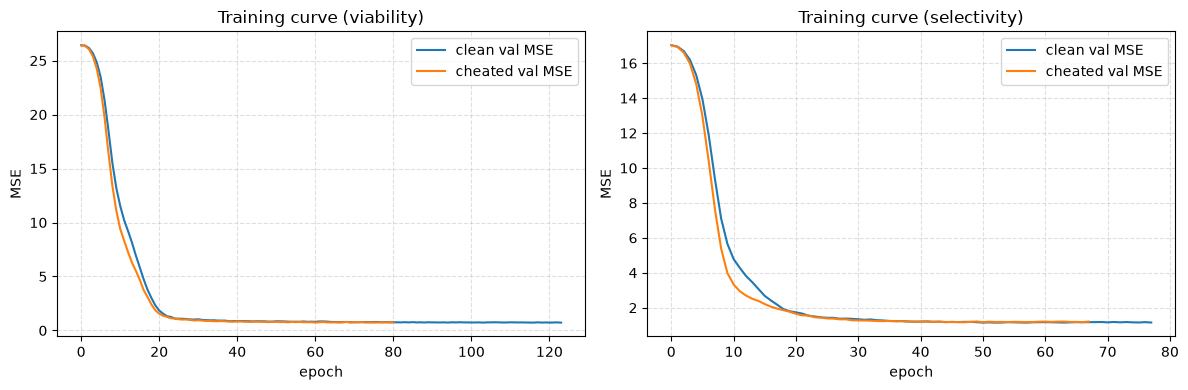

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, h_clean, h_cheat, name in [(axes[0], hist_viab_clean, hist_viab_cheat, "viability"),
                                    (axes[1], hist_sel_clean,  hist_sel_cheat,  "selectivity")]:
    ax.plot(h_clean["val_loss"], label="clean val MSE")
    ax.plot(h_cheat["val_loss"], label="cheated val MSE")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
    ax.set_title(f"Training curve ({name})")
    ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

## 7. Test-set generalization: did cheating break anything?

`X_test` never contains any of the TRUE top-500 (checked in section 3), so this is a clean check that
adding 500 extreme points to an ~8,500-row training set didn't wreck the model's fit on the ordinary
population.

In [17]:
pred_viab_test_clean = np.asarray(predict_log_enrichment(model_viab_clean, jnp.asarray(X_test)))
pred_viab_test_cheat = np.asarray(predict_log_enrichment(model_viab_cheat, jnp.asarray(X_test)))
pred_sel_test_clean  = np.asarray(predict_log_enrichment(model_sel_clean,  jnp.asarray(X_test)))
pred_sel_test_cheat  = np.asarray(predict_log_enrichment(model_sel_cheat,  jnp.asarray(X_test)))

print(f"{'model':16s}  {'viab test r':>12s}  {'sel test r':>11s}")
print(f"{'clean':16s}  {pearson(y_viab_test, pred_viab_test_clean):12.4f}  {pearson(y_sel_test, pred_sel_test_clean):11.4f}")
print(f"{'cheated':16s}  {pearson(y_viab_test, pred_viab_test_cheat):12.4f}  {pearson(y_sel_test, pred_sel_test_cheat):11.4f}")

model              viab test r   sel test r
clean                   0.9680       0.9376
cheated                 0.9682       0.9378


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Two different populations appear together in the section-8 figure: the crimson lines are still the GLOBAL/THEORETICAL top-500 (<code>best_seqs_viab</code>/<code>best_seqs_sel</code>, section 3, now also in training data for the cheated models); the gray histogram is a separate <b>RANDOM SYNTHETIC BASELINE</b> — <code>X_big</code>, 2,000,000 unoptimized random sequences (<code>dataset_anti2</code>) — used only as a reference distribution, not a "top" of anything.
</div>

## 8. Where do the TRUE-best variants land in each model's predicted distribution?

Same "Where do the TRUE-best variants land?" plot as the sibling notebooks: grey = predicted-score
distribution over the 2M-variant random background, red lines = the model's own predictions on the
TRUE top-500. For the cheated models these 500 points were literally training data -- if the plain MLP
can fit them at all, the red lines should now cluster tightly at the right edge instead of spreading
across the distribution the way the clean baseline's do.

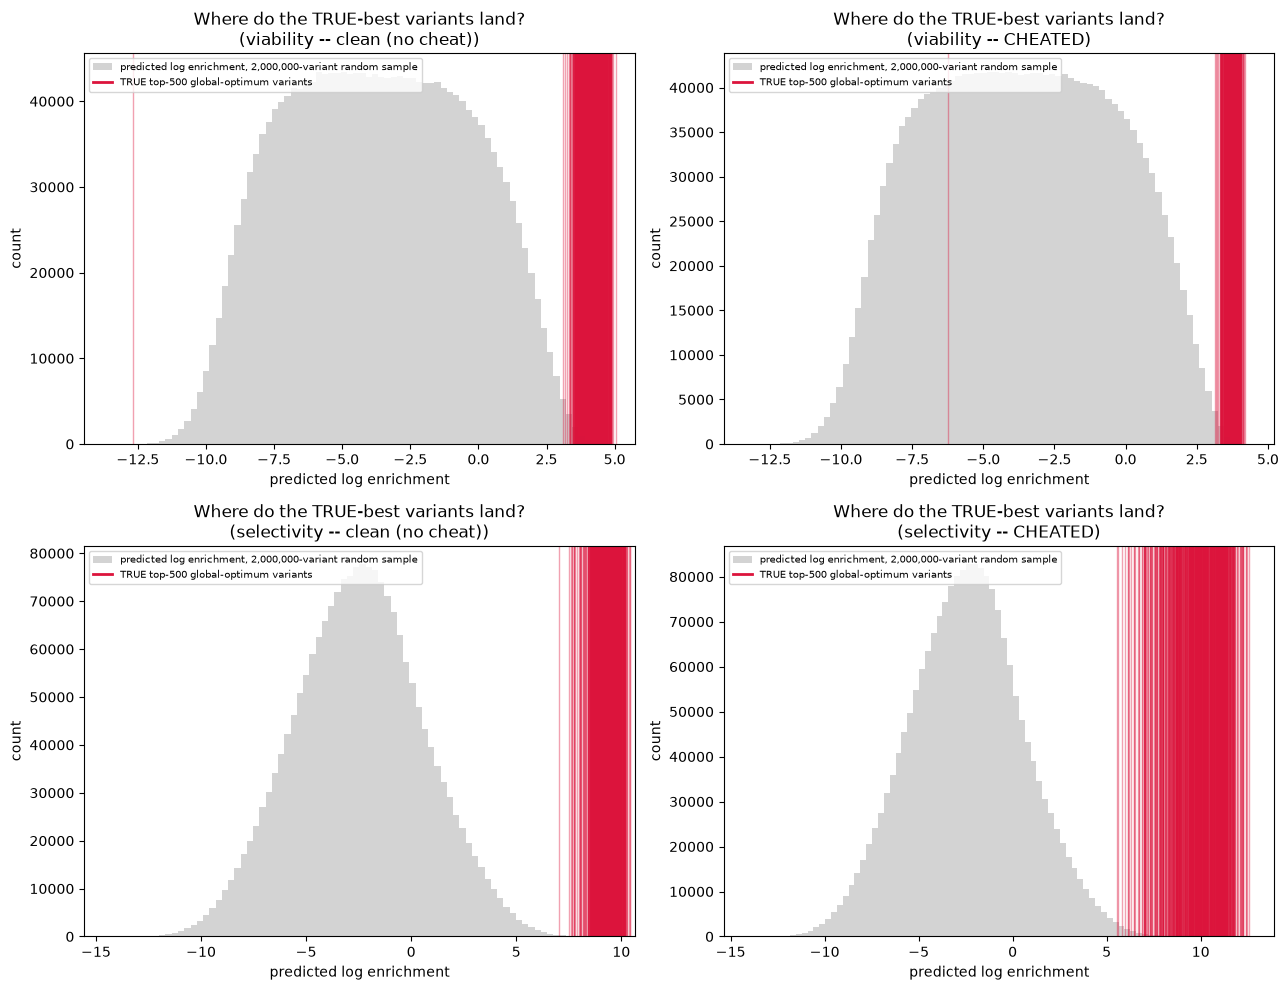

In [18]:
pred_best_viab_clean = np.asarray(predict_log_enrichment(model_viab_clean, jnp.asarray(X_best_viab)))
pred_best_viab_cheat = np.asarray(predict_log_enrichment(model_viab_cheat, jnp.asarray(X_best_viab)))
pred_best_sel_clean  = np.asarray(predict_log_enrichment(model_sel_clean,  jnp.asarray(X_best_sel)))
pred_best_sel_cheat  = np.asarray(predict_log_enrichment(model_sel_cheat,  jnp.asarray(X_best_sel)))

pred_viab_big_clean = np.asarray(predict_log_enrichment(model_viab_clean, jnp.asarray(X_big)))
pred_viab_big_cheat = np.asarray(predict_log_enrichment(model_viab_cheat, jnp.asarray(X_big)))
pred_sel_big_clean  = np.asarray(predict_log_enrichment(model_sel_clean,  jnp.asarray(X_big)))
pred_sel_big_cheat  = np.asarray(predict_log_enrichment(model_sel_cheat,  jnp.asarray(X_big)))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
panels = [
    (axes[0, 0], pred_viab_big_clean, pred_best_viab_clean, "viability -- clean (no cheat)"),
    (axes[0, 1], pred_viab_big_cheat, pred_best_viab_cheat, "viability -- CHEATED"),
    (axes[1, 0], pred_sel_big_clean,  pred_best_sel_clean,  "selectivity -- clean (no cheat)"),
    (axes[1, 1], pred_sel_big_cheat,  pred_best_sel_cheat,  "selectivity -- CHEATED"),
]
for ax, pred_pop, pred_best, name in panels:
    ax.hist(pred_pop, bins=80, color="lightgray",
            label=f"predicted log enrichment, {len(pred_pop):,}-variant random sample")
    for v in pred_best:
        ax.axvline(v, color="crimson", alpha=0.4, lw=1)
    ax.axvline(pred_best[0], color="crimson", lw=2, label=f"TRUE top-{K_BEST} global-optimum variants")
    ax.set_xlabel("predicted log enrichment")
    ax.set_ylabel("count")
    ax.set_title(f"Where do the TRUE-best variants land?\n({name})")
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

In [19]:
# Recovery quantification -- same "worst of top-K beats X% of background" metric used to
# evaluate the credible GT in AAV9_profile_model.ipynb's REG_STRENGTH sweep, applied here to
# compare clean vs. augmented training per task.
def pct_beats_background(pred_best, pred_pop):
    return 100 * (pred_pop < pred_best.min()).mean()

print(f"{'model':30s}  {'worst-of-top-500 beats % of 2M background':>44s}")
for name, pred_best, pred_pop in [
    ("viability, clean",       pred_best_viab_clean, pred_viab_big_clean),
    ("viability, augmented",   pred_best_viab_cheat, pred_viab_big_cheat),
    ("selectivity, clean",     pred_best_sel_clean,  pred_sel_big_clean),
    ("selectivity, augmented", pred_best_sel_cheat,  pred_sel_big_cheat),
]:
    print(f"{name:30s}  {pct_beats_background(pred_best, pred_pop):44.1f}")


model                              worst-of-top-500 beats % of 2M background
viability, clean                                                         0.0
viability, augmented                                                    26.0
selectivity, clean                                                     100.0
selectivity, augmented                                                  99.6


## 9. Quantify: does the residual still correlate with `J_part`?

Decomposes each TRUE top-500 variant's ground-truth score into `F_part`/`J_part` (same recipe as the
sibling notebooks), then checks whether `residual = predicted - true` still tracks `J_part` for the
cheated model the way it does for the clean baseline. If cheating worked, `r(residual, J_part)` should
shrink toward 0 and `mean |residual|` should drop sharply for the cheated rows relative to clean.

In [20]:
def compute_F_only(seq, F, L=NUM_POSITIONS):
    """Additive part of compute_score_array -- same F[seq, arange(L)] term, without J."""
    return jnp.sum(F[seq, jnp.arange(L)], axis=1)

F_part_viab = np.asarray(compute_F_only(jnp.asarray(best_seqs_viab), F_viab))
J_part_viab = np.asarray(best_scores_viab) - F_part_viab

F_part_sel = np.asarray(compute_F_only(jnp.asarray(best_seqs_sel), F_sel_anti))
J_part_sel = np.asarray(best_scores_sel) - F_part_sel

residual_viab_clean = pred_best_viab_clean - best_scores_viab
residual_viab_cheat = pred_best_viab_cheat - best_scores_viab
residual_sel_clean  = pred_best_sel_clean  - best_scores_sel
residual_sel_cheat  = pred_best_sel_cheat  - best_scores_sel

print(f"{'group':22s}  {'r(resid, F_part)':>17s}  {'r(resid, J_part)':>17s}  {'mean |resid|':>12s}")
for label, resid, F_p, J_p in [
    ("viability, clean",     residual_viab_clean, F_part_viab, J_part_viab),
    ("viability, cheated",   residual_viab_cheat, F_part_viab, J_part_viab),
    ("selectivity, clean",   residual_sel_clean,  F_part_sel,  J_part_sel),
    ("selectivity, cheated", residual_sel_cheat,  F_part_sel,  J_part_sel),
]:
    print(f"{label:22s}  {pearson(resid, F_p):17.4f}  {pearson(resid, J_p):17.4f}  {np.mean(np.abs(resid)):12.3f}")

group                    r(resid, F_part)   r(resid, J_part)  mean |resid|
viability, clean                   0.9448            -0.9525         5.114
viability, cheated                 0.8862            -0.9027         5.529
selectivity, clean                 0.4841            -0.6366         5.398
selectivity, cheated              -0.0486            -0.0070         4.801


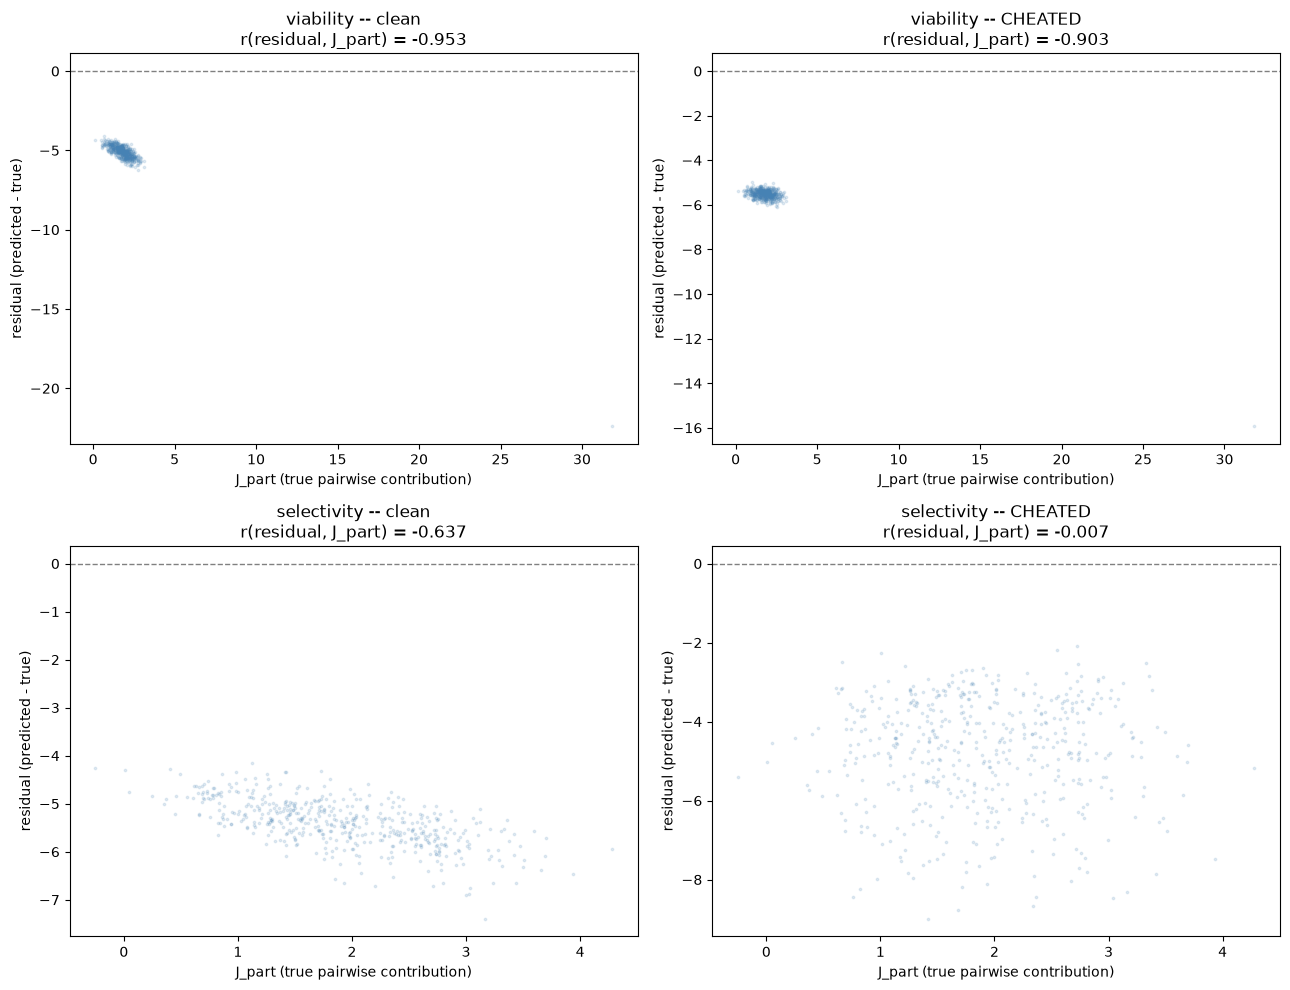

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
panels = [
    (axes[0, 0], J_part_viab, residual_viab_clean, "viability -- clean"),
    (axes[0, 1], J_part_viab, residual_viab_cheat, "viability -- CHEATED"),
    (axes[1, 0], J_part_sel,  residual_sel_clean,  "selectivity -- clean"),
    (axes[1, 1], J_part_sel,  residual_sel_cheat,  "selectivity -- CHEATED"),
]
for ax, J_p, resid, name in panels:
    r = pearson(J_p, resid)
    ax.scatter(J_p, resid, s=3, alpha=0.15, color="steelblue")
    ax.axhline(0, color="gray", lw=1, ls="--")
    ax.set_xlabel("J_part (true pairwise contribution)")
    ax.set_ylabel("residual (predicted - true)")
    ax.set_title(f"{name}\nr(residual, J_part) = {r:.3f}")
fig.tight_layout()
plt.show()

## 10. Verdict

In [22]:
def variance_share(F_part, J_part):
    var_F, var_J = np.var(F_part), np.var(J_part)
    cov_FJ = np.cov(F_part, J_part)[0, 1]
    var_total = var_F + var_J + 2 * cov_FJ
    return 100 * var_F / var_total, 100 * var_J / var_total

pf, pj = variance_share(F_part_viab, J_part_viab)
print(f"Reminder -- among the TRUE top-{K_BEST} viability variants, J explains {pj:.1f}% of the")
print(f"score variance vs F's {pf:.1f}%.")
print()
print(f"{'group':22s}  {'mean |resid| (clean)':>21s}  {'mean |resid| (augmented)':>24s}")
for name, resid_c, resid_ch in [
    ("viability",   residual_viab_clean, residual_viab_cheat),
    ("selectivity", residual_sel_clean,  residual_sel_cheat),
]:
    print(f"{name:22s}  {np.mean(np.abs(resid_c)):21.3f}  {np.mean(np.abs(resid_ch)):24.3f}")
print()
print("Note: unlike the notebook's original design, the AUGMENTED models were never handed the exact")
print("noiseless compute_score for the injected top-500 -- they were trained on a REALISTIC NGS-")
print("simulated log enrichment for those variants (section 5), the same noisy measurement process as")
print("every other sequence in the pool. `residual` above is still computed against the noiseless")
print("ground truth (best_scores_*), since that's the quantity we actually care about recovering.")
print()
print("If augmentation works: mean |residual| for 'augmented' should drop below 'clean', r(residual,")
print("J_part) should shrink toward 0, and the section-8 histograms' lines should cluster further")
print("right for the AUGMENTED panels than the clean ones -- meaning the plain MLP CAN learn to")
print("recognize these J-dominated points from a realistically-noisy augmented library, so the earlier")
print("failure (section 4 of MLP_for_anticorrelated_weights.ipynb / section 5 of")
print("MLP_bilinear_head_anticorrelated.ipynb) is mostly an out-of-distribution / library-composition")
print("problem that a designed library could practically fix.")
print()
print("If augmentation does NOT help (or the injected variants' realistic labels are themselves so")
print("noisy/regressed-to-the-mean that they don't teach the model much): the plain MLP still struggles")
print("with this bilinear structure even when the library is enriched with genuinely good designs --")
print("closer to a capacity/optimization limit, or evidence that realistic NGS noise itself destroys")
print("most of the signal a 'cheat' would otherwise provide.")

Reminder -- among the TRUE top-500 viability variants, J explains 21330.7% of the
score variance vs F's 20761.3%.

group                    mean |resid| (clean)  mean |resid| (augmented)
viability                               5.114                     5.529
selectivity                             5.398                     4.801

Note: unlike the notebook's original design, the AUGMENTED models were never handed the exact
noiseless compute_score for the injected top-500 -- they were trained on a REALISTIC NGS-
simulated log enrichment for those variants (section 5), the same noisy measurement process as
every other sequence in the pool. `residual` above is still computed against the noiseless
ground truth (best_scores_*), since that's the quantity we actually care about recovering.

If augmentation works: mean |residual| for 'augmented' should drop below 'clean', r(residual,
J_part) should shrink toward 0, and the section-8 histograms' lines should cluster further
right for the AUGMENT